# Reglas de Asociación — Market Basket Analysis con Apriori

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** IA & Big Data · Minería de Datos · Reglas de Asociación

---

### Objetivo

Identificar qué productos se compran juntos en un supermercado para apoyar decisiones de
cross-selling, distribución en el lineal y promociones combinadas ("quien compra A, también
compra B").

### Contexto de negocio

**El cliente:** un supermercado que quiere decidir qué productos colocar cerca en el
lineal, qué combos promocionar y qué recomendar en caja o en la app.

**El problema:** con 25 productos y 10.000 tickets, las asociaciones no son evidentes a
simple vista — hacen falta métricas objetivas (support, confidence, lift) para separar una
asociación real de una coincidencia.

**La pregunta:** ¿qué pares y combinaciones de productos aparecen juntos con más frecuencia
de la esperada por azar, y son lo bastante fuertes como para actuar sobre ellas?

**Dataset:** 10.000 transacciones simuladas (`transaction_id`, `items`, `n_items`), 25
productos distintos.

**Dos enfoques, de menos a más escalable:**
1. Cálculo manual de support/confidence/lift para **pares** de productos — para entender
   la matemática de las reglas de asociación sin caja negra.
2. Algoritmo **Apriori** (librería `mlxtend`) para encontrar conjuntos frecuentes de
   **3 o más productos**, algo inabordable a mano por el número de combinaciones.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

## 1. Carga y exploración del dataset

In [ ]:
data = pd.read_excel("transacciones_supermercado.xlsx")

print(f"Transacciones: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Transacciones: 10000 | Columnas: 3


,transaction_id,items,n_items
0,1,"Cereales, Patatas, Queso",3
1,2,"Huevos, Mantequilla, Pan, Pan_Tostado, Pasta, ...",6
2,3,"Cereales, Galletas, Leche, Pan, Pan_Tostado, R...",6
3,4,"Café, Cereales, Galletas, Helado, Leche, Pan, ...",8
4,5,"Atún, Café, Pan, Pizza_Congelada, Queso, Refre...",8


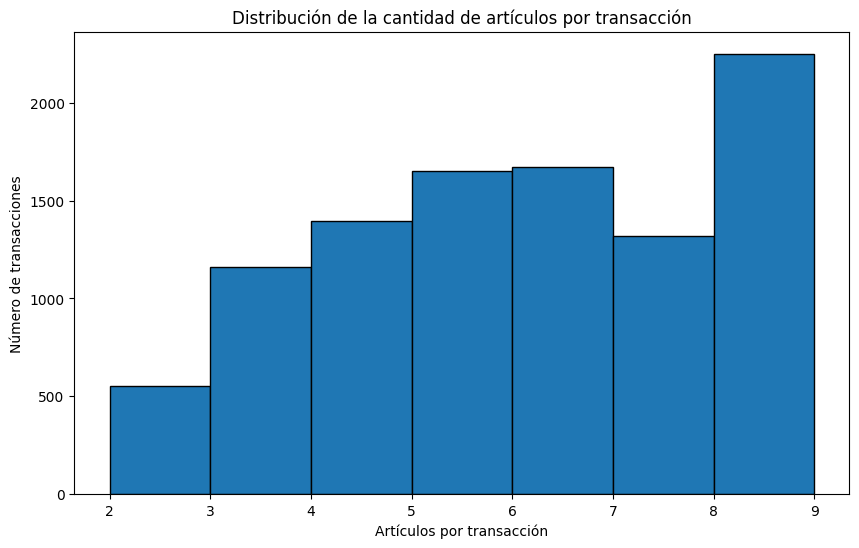

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    data["n_items"],
    bins=range(
        data["n_items"].min(),
        data["n_items"].max() + 2
    ),
    edgecolor="black"
)

plt.title("Distribución de la cantidad de artículos por transacción")
plt.xlabel("Artículos por transacción")
plt.ylabel("Número de transacciones")
plt.show()

## 2. Enfoque manual — support, confidence y lift para pares de productos

- **Support(A→B):** en qué fracción de todas las transacciones aparecen A y B juntos.
- **Confidence(A→B):** de las transacciones que tienen A, en qué fracción también aparece B.
- **Lift(A→B):** cuánto más probable es B cuando ya tenemos A, frente a la probabilidad
  base de B (lift > 1 indica asociación positiva real, no casualidad).

In [ ]:
# Cada transacción como un set de productos
transactions = [
    set(items.split(", "))
    for items in data["items"]
]

N = len(transactions)
print(f"Total de transacciones: {N}")

Total de transacciones: 10000


In [ ]:
# Contar cuántas veces aparece cada producto en todas las transacciones
items_counts = Counter(
    item
    for transaction in transactions
    for item in transaction
)

# Support individual de cada producto
item_support = {
    item: count / N
    for item, count in items_counts.items()
}

support_df = pd.DataFrame(
    list(item_support.items()),
    columns=["Producto", "support"]
).sort_values(by="support", ascending=False).reset_index(drop=True)

support_df

,Producto,support
0,Pan,0.3245
1,Leche,0.3157
2,Fruta,0.3152
3,Huevos,0.3055
4,Café,0.2954
5,Queso,0.2872
6,Cereales,0.2777
7,Verdura,0.2739
8,Mantequilla,0.2469
9,Refrescos,0.2362


In [ ]:
# Contador de pares de productos que aparecen juntos en la misma transacción.
#
# El bucle interno debe ir DENTRO del bucle externo (una pasada por transacción):
# si se desindenta, Python solo lo ejecuta una vez con los "items" de la última
# transacción del bucle, subcontando drásticamente los pares reales.

pair_counts = Counter()

for transaction in transactions:
    # Ordenamos los productos de la cesta para que los pares sean consistentes
    items = sorted(transaction)

    # Generamos todas las combinaciones de pares de productos 2 a 2
    for i, producto_a in enumerate(items):
        for producto_b in items[i + 1:]:
            pair_counts[(producto_a, producto_b)] += 1

print(f"Total de pares de productos: {len(pair_counts)}")
print(pair_counts.most_common(10))

Total de pares de productos: 300
[(('Cereales', 'Leche'), 1323), (('Pan', 'Queso'), 1263), (('Café', 'Leche'), 1217), (('Mantequilla', 'Pan'), 1189), (('Huevos', 'Pan'), 1184), (('Fruta', 'Pan'), 963), (('Fruta', 'Huevos'), 955), (('Leche', 'Pan'), 950), (('Fruta', 'Yogur'), 943), (('Fruta', 'Leche'), 937)]


In [ ]:
# Calculamos las reglas de asociación y sus métricas para cada par.
# El DataFrame se construye UNA sola vez, al terminar de recorrer todos los pares
# (no dentro del bucle, y no a partir de "rules.append" — eso pasa el propio método
# `list.append` como dato, en vez de la lista `rules` ya rellenada).

rules = []

for (producto_a, producto_b), count_ab in pair_counts.items():
    count_a = items_counts[producto_a]
    count_b = items_counts[producto_b]

    support_ab = count_ab / N

    confidence_a_to_b = count_ab / count_a
    confidence_b_to_a = count_ab / count_b

    lift_a_to_b = confidence_a_to_b / item_support[producto_b]
    lift_b_to_a = confidence_b_to_a / item_support[producto_a]

    rules.append({
        "Producto A": producto_a,
        "Producto B": producto_b,
        "Support": support_ab,
        "Confidence A->B": confidence_a_to_b,
        "Confidence B->A": confidence_b_to_a,
        "Lift A->B": lift_a_to_b,
        "Lift B->A": lift_b_to_a
    })

rules_df = pd.DataFrame(rules)
print(f"Total de reglas generadas: {len(rules_df)}")
rules_df.sort_values("Lift A->B", ascending=False).head(10)

Total de reglas generadas: 300


,Producto A,Producto B,Support,Confidence A->B,Confidence B->A,Lift A->B,Lift B->A
17,Pasta,Salsa_Tomate,0.0894,0.425309,0.408779,1.944715,1.944715
154,Chocolate,Helado,0.0462,0.296534,0.299223,1.920557,1.920557
70,Pizza_Congelada,Refrescos,0.0544,0.408408,0.230313,1.729079,1.729079
117,Cerveza,Patatas,0.0785,0.397670,0.336332,1.703812,1.703812
75,Queso,Vino,0.0783,0.272632,0.471119,1.640387,1.640387
9,Mantequilla,Pan_Tostado,0.0733,0.296881,0.401204,1.624966,1.624966
180,Arroz,Pollo,0.0566,0.319053,0.277451,1.563985,1.563985
19,Cereales,Leche,0.1323,0.476413,0.419069,1.509070,1.509070
8,Mantequilla,Pan,0.1189,0.481571,0.366410,1.484042,1.484042
225,Fruta,Yogur,0.0943,0.299175,0.446496,1.416549,1.416549


In [ ]:
# Filtrado de reglas por support, confidence y lift mínimos,
# para quedarnos con las asociaciones realmente accionables.

MIN_SUPPORT = 0.08
MIN_CONFIDENCE = 0.35
MIN_LIFT = 1.15

rules_filtered = rules_df[
    (rules_df["Support"] >= MIN_SUPPORT) &
    (rules_df["Confidence A->B"] >= MIN_CONFIDENCE) &
    (rules_df["Lift A->B"] >= MIN_LIFT)
].sort_values("Lift A->B", ascending=False).reset_index(drop=True)

print(f"Reglas por encima de los umbrales: {len(rules_filtered)}")
rules_filtered

Reglas por encima de los umbrales: 6


,Producto A,Producto B,Support,Confidence A->B,Confidence B->A,Lift A->B,Lift B->A
0,Pasta,Salsa_Tomate,0.0894,0.425309,0.408779,1.944715,1.944715
1,Cereales,Leche,0.1323,0.476413,0.419069,1.509070,1.509070
2,Mantequilla,Pan,0.1189,0.481571,0.366410,1.484042,1.484042
3,Pan,Queso,0.1263,0.389214,0.439763,1.355203,1.355203
4,Café,Leche,0.1217,0.411984,0.385493,1.304985,1.304985
5,Huevos,Pan,0.1184,0.387561,0.364869,1.194334,1.194334


## 3. Visualización interactiva de las reglas filtradas

In [ ]:
import plotly.express as px

rules_filtered["regla"] = (
    rules_filtered["Producto A"]
    + " → "
    + rules_filtered["Producto B"]
)

fig = px.scatter(
    rules_filtered,
    x="Support",
    y="Confidence A->B",
    size="Lift A->B",
    hover_name="regla",
    hover_data={
        "Support": ":.3f",
        "Confidence A->B": ":.3f",
        "Lift A->B": ":.3f",
        "Producto A": True,
        "Producto B": True
    },
    title="Reglas de asociación filtradas: Support vs Confidence (tamaño = Lift)",
    labels={
        "Support": "Support",
        "Confidence A->B": "Confidence",
        "Lift A->B": "Lift"
    }
)

fig.update_layout(width=1000, height=650, hovermode="closest")
fig.show()

## 4. Enfoque profesional — Apriori con mlxtend (conjuntos de 3 o más productos)

El cálculo manual de pares no escala: para conjuntos de 3+ productos el número de
combinaciones crece factorialmente. El algoritmo **Apriori** poda el espacio de búsqueda
usando la propiedad de que un conjunto solo puede ser frecuente si todos sus subconjuntos
también lo son, lo que lo hace viable en la práctica.

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Convertir cada transacción a lista de productos
transactions_list = data["items"].apply(lambda x: x.split(", ")).tolist()

# One-hot encoding: una columna booleana por producto
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)

basket_encoded = pd.DataFrame(te_ary, columns=te.columns_)
basket_encoded.head()

,Arroz,Atún,Café,Cereales,Cerveza,Chocolate,Fruta,Galletas,Helado,Huevos,...,Patatas,Pizza_Congelada,Pollo,Queso,Refrescos,Salsa_Tomate,Té,Verdura,Vino,Yogur
0,False,False,False,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
3,False,False,True,True,False,False,False,True,True,False,...,False,False,True,False,False,True,False,False,False,False
4,False,True,True,False,False,False,False,False,False,False,...,False,True,False,True,True,False,False,True,True,False


In [ ]:
# Conjuntos frecuentes de cualquier tamaño (hasta 5 productos)
frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.03,
    use_colnames=True,
    max_len=5
)

frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)

print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")
frequent_itemsets.sort_values("support", ascending=False).head(10)

Conjuntos frecuentes encontrados: 296


,support,itemsets,itemset_size
12,0.3245,(Pan),1
10,0.3157,(Leche),1
6,0.3152,(Fruta),1
9,0.3055,(Huevos),1
2,0.2954,(Café),1
18,0.2872,(Queso),1
3,0.2777,(Cereales),1
22,0.2739,(Verdura),1
11,0.2469,(Mantequilla),1
19,0.2362,(Refrescos),1


In [ ]:
# Reglas de asociación a partir de todos los conjuntos frecuentes
rules_multi = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

rules_multi["antecedent_size"] = rules_multi["antecedents"].apply(len)
rules_multi["consequent_size"] = rules_multi["consequents"].apply(len)
rules_multi["total_items"] = (
    rules_multi["antecedent_size"] + rules_multi["consequent_size"]
)

# Nos quedamos con las reglas que combinan 3 o más productos en total
rules_3plus = rules_multi[
    rules_multi["total_items"] >= 3
].sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Reglas con 3+ productos: {len(rules_3plus)}")

Reglas con 3+ productos: 118


In [ ]:
def convertir_regla(conjunto):
    return ", ".join(sorted(conjunto))


rules_3plus["antecedent"] = rules_3plus["antecedents"].apply(convertir_regla)
rules_3plus["consequent"] = rules_3plus["consequents"].apply(convertir_regla)

rules_3plus["regla"] = (
    "{" + rules_3plus["antecedent"] + "}"
    + " → "
    + "{" + rules_3plus["consequent"] + "}"
)

rules_3plus[
    [
        "regla",
        "support",
        "confidence",
        "lift",
        "antecedent_size",
        "consequent_size",
        "total_items"
    ]
].head(20)

,regla,support,confidence,lift,antecedent_size,consequent_size,total_items
0,"{Pan, Pan_Tostado} → {Mantequilla}",0.0336,0.533333,2.160119,2,1,3
1,"{Mantequilla} → {Pan, Pan_Tostado}",0.0336,0.136087,2.160119,1,2,3
2,"{Queso} → {Pan, Vino}",0.0318,0.110724,2.035372,1,2,3
3,"{Pan, Vino} → {Queso}",0.0318,0.584559,2.035372,2,1,3
4,"{Pan} → {Mantequilla, Queso}",0.0426,0.131279,1.841219,1,2,3
5,"{Mantequilla, Queso} → {Pan}",0.0426,0.597475,1.841219,2,1,3
6,"{Café, Cereales} → {Leche}",0.0478,0.571087,1.808955,2,1,3
7,"{Leche} → {Café, Cereales}",0.0478,0.151410,1.808955,1,2,3
8,"{Café} → {Galletas, Leche}",0.0328,0.111036,1.692620,1,2,3
9,"{Galletas, Leche} → {Café}",0.0328,0.500000,1.692620,2,1,3


## 5. Conclusión

**El hallazgo:** el enfoque manual, correctamente calculado, ya revela asociaciones fuertes
entre pares de productos — **Pasta → Salsa de Tomate** (lift 1,94) es la más clara del
catálogo, seguida de Chocolate → Helado y Pizza Congelada → Refrescos. Pero solo Apriori
permite ver el siguiente nivel: **118 reglas con 3 o más productos**, como
`{Pan, Pan_Tostado} → {Mantequilla}` (lift 2,16), invisibles para el análisis por pares.

**Recomendaciones:**
1. **Colocación en el lineal (impacto: alto):** situar Pasta junto a Salsa de Tomate, y
   Pan/Pan Tostado cerca de Mantequilla — la proximidad física convierte una compra
   planificada en una compra por impulso del producto asociado.
2. **Promociones combinadas (impacto: medio):** los packs de 3 productos con mayor lift
   (p. ej. Café + Cereales → Leche) son mejores candidatos a descuento cruzado que
   descuentos genéricos, porque atacan una asociación de compra ya demostrada.
3. **Recomendador en caja/app (impacto: medio):** las reglas con confidence alta (≥ 0,45)
   son las más fiables para un "también te puede interesar" automático — arriesgan menos
   falsos positivos que las de confidence baja aunque tengan buen lift.

**Límite del análisis:** support, confidence y lift describen co-ocurrencia, no causalidad
— una regla fuerte no explica *por qué* se compran juntos (recetas, hábito, proximidad ya
existente en tienda), así que las recomendaciones de colocación deben validarse con una
prueba A/B antes de generalizarlas a todo el catálogo.